# 🚗 Uber Ride Analytics — Exploratory Data Analysis

## 📌 Project Overview

This project explores **Uber ride-booking data from 2024** to understand booking patterns, customer and driver behavior, vehicle performance, cancellations, revenue, and ride satisfaction.

Rather than focusing only on descriptive statistics, this analysis aims to answer **business-oriented questions** and uncover patterns that could help improve operational efficiency and customer experience.

### 🎯 Objectives

The analysis will focus on:

* 📈 Understanding **booking and demand patterns** over time
* 🚗 Comparing **vehicle types and their performance**
* 🚫 Investigating **customer and driver cancellations**
* 💰 Analyzing **revenue and payment methods**
* 📍 Exploring **pickup and drop-off locations**
* ⭐ Understanding **customer and driver ratings**
* ⏱️ Investigating **waiting and trip durations**
* 🔎 Exploring relationships between operational and financial variables

### 🛠️ Tools & Technologies

* **Python**
* **NumPy** — numerical analysis
* **Pandas** — data manipulation and analysis
* **Matplotlib, Seaborn & Plotly** — data visualization

---

## 📊 Dataset

The dataset contains approximately **148K booking records** from 2024 and includes information about:

* Booking status
* Vehicle type
* Pickup and drop-off locations
* Ride distance
* Booking value
* Customer and driver cancellations
* Cancellation reasons
* Waiting and trip times
* Customer and driver ratings
* Payment methods

> **Note:** Dataset-level statistics and assumptions will be independently validated during the data-quality and exploration stages rather than being taken directly from the dataset description.


In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)

# Reading Data and Investgating

In [2]:
uber_data_path = os.path.join('dataset', 'ncr_ride_bookings.csv')

df = pd.read_csv(uber_data_path)

df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

- There are 21 **columns** and 150000 **row**
- There are null values

In [4]:
df.describe()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000


In [5]:
df.duplicated().sum()

0

In [6]:
null_columns = df.columns[df.isna().sum() > 0]

df[null_columns].isna().sum()

Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [7]:
for col in null_columns:
    print(f"values of {col}: ")
    print(df[col].value_counts())
    print("=" * 50)
    print('\n')

values of Avg VTAT: 
Avg VTAT
9.4     1259
6.0     1249
5.8     1248
9.5     1246
6.5     1239
        ... 
19.1      59
19.5      57
18.5      56
18.9      55
20.0      38
Name: count, Length: 181, dtype: int64


values of Avg CTAT: 
Avg CTAT
24.8    401
25.9    389
28.1    388
20.5    386
25.3    383
       ... 
11.1     34
11.6     34
14.5     32
13.8     27
10.0     23
Name: count, Length: 351, dtype: int64


values of Cancelled Rides by Customer: 
Cancelled Rides by Customer
1.0    10500
Name: count, dtype: int64


values of Reason for cancelling by Customer: 
Reason for cancelling by Customer
Wrong Address                                   2362
Change of plans                                 2353
Driver is not moving towards pickup location    2335
Driver asked to cancel                          2295
AC is not working                               1155
Name: count, dtype: int64


values of Cancelled Rides by Driver: 
Cancelled Rides by Driver
1.0    27000
Name: count, dtype: int6

In [8]:
df['Booking Status'].value_counts()

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

In [9]:
df.groupby('Booking Status')[null_columns].count()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
Booking Status,,,,,,,,,,,,,
Cancelled by Customer,10500,0,10500,10500,0,0,0,0,0,0,0,0,0
Cancelled by Driver,27000,0,0,0,27000,27000,0,0,0,0,0,0,0
Completed,93000,93000,0,0,0,0,0,0,93000,93000,93000,93000,93000
Incomplete,9000,9000,0,0,0,0,9000,9000,9000,9000,0,0,9000
No Driver Found,0,0,0,0,0,0,0,0,0,0,0,0,0


- Now we understand that the null values are from the booking status where if the ride was completed all the other columns will be null

# Timestamp processing and preprocessing data

In [10]:
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S')

df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['month_name'] = df['Date'].dt.month_name()
df['day'] = df['Date'].dt.day
df['day_of_week'] = df['Date'].dt.day_name()

df['hour'] = df['Time'].dt.hour
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,year,month,month_name,day,day_of_week,hour
0,2024-03-23,1900-01-01 12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024,3,March,23,Saturday,12
1,2024-11-29,1900-01-01 18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,2024,11,November,29,Friday,18
2,2024-08-23,1900-01-01 08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card,2024,8,August,23,Friday,8
3,2024-10-21,1900-01-01 17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI,2024,10,October,21,Monday,17
4,2024-09-16,1900-01-01 22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI,2024,9,September,16,Monday,22


In [11]:
categorical_columns = df.select_dtypes(include='object').columns
numerical_columns = df.select_dtypes(include='number').columns

# 1. Booking & Demand Analysis

## 1- What days/months have the highest booking volume?

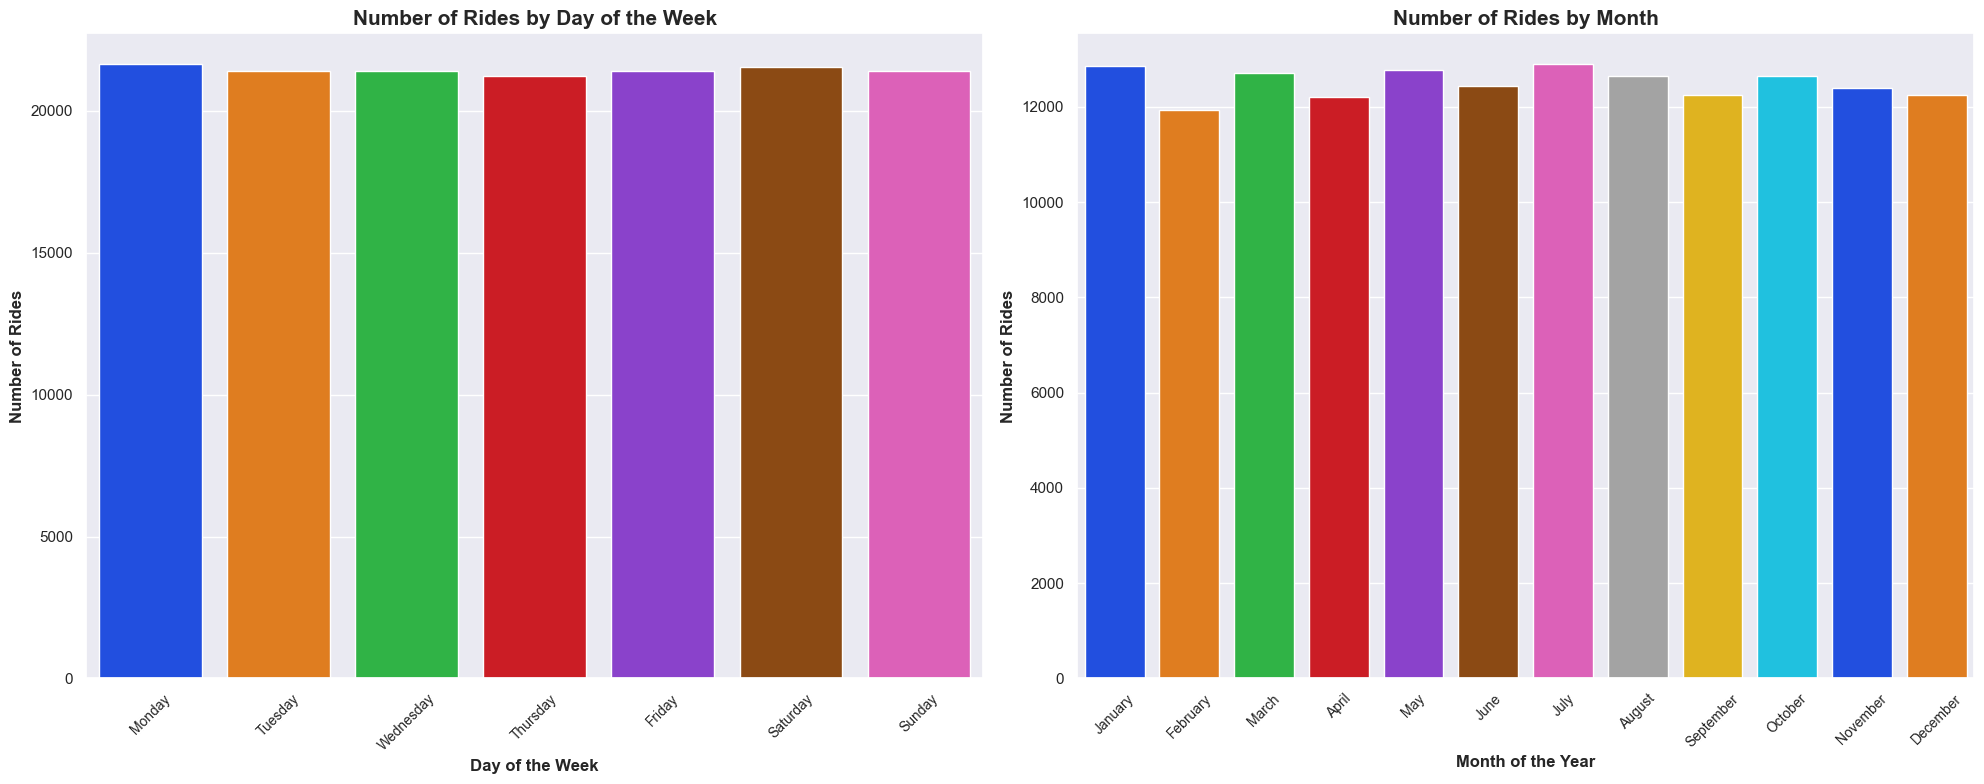

In [12]:
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

sns.set_theme(style='darkgrid')
plt.figure(figsize=(20, 8))

# Day of the Week
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='day_of_week', palette='bright', order=day_order)
plt.title('Number of Rides by Day of the Week', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, fontsize=10)
plt.xlabel('Day of the Week', fontsize=12, fontweight='bold')
plt.ylabel('Number of Rides', fontsize=12, fontweight='bold')

# Month of the Year
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='month_name', palette='bright', order=month_order)
plt.title('Number of Rides by Month', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, fontsize=10)
plt.xlabel('Month of the Year', fontsize=12, fontweight='bold')
plt.ylabel('Number of Rides', fontsize=12, fontweight='bold')


plt.tight_layout()
plt.show()

### Key Insights

- **Monday** recorded the highest booking volume, while **Thursday** recorded the lowest. However, the differences across the days of the week are relatively small, suggesting that booking demand remains fairly consistent throughout the week.

- **July and January** recorded the highest booking volumes, while **February** had the lowest. However, February has only **28 days**, compared with 30 or 31 days in the other months, which partly explains its lower total booking volume. Therefore, comparing **average daily bookings** would provide a fairer comparison between months.

## 2- What hours have the highest demand?

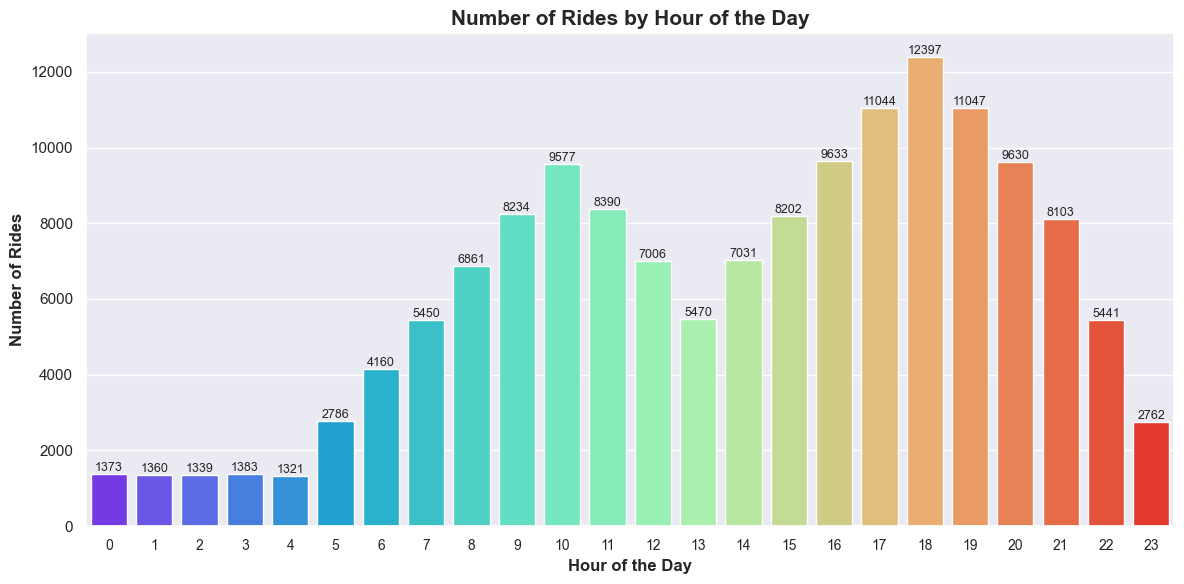

In [13]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(x = df['hour'], palette='rainbow')

for container in ax.containers:
    ax.bar_label(container, fontsize=9)

plt.title('Number of Rides by Hour of the Day', fontsize=15, fontweight='bold')
plt.xticks(fontsize=10)
plt.xlabel('Hour of the Day', fontsize=12, fontweight='bold')
plt.ylabel('Number of Rides', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Insights

- **Peak hour:** 6 PM, which recorded the highest booking volume.

- **Lowest booking volume:** The period from **12 AM to 4 AM** recorded the lowest number of bookings.

- **Rush-hour pattern:** Booking volume shows noticeable peaks during the **morning (around 9–11 AM)** and **evening (around 6–8 PM)**, with the evening period showing the strongest demand.

- **Hourly trend:** Booking volume gradually increases from the early morning, reaching a morning peak around **9–10 AM**, then decreases toward the early afternoon. Demand increases again throughout the afternoon and reaches its highest point around **7 PM**, before declining during the night.

## 3- Which pickup locations generate the most bookings?

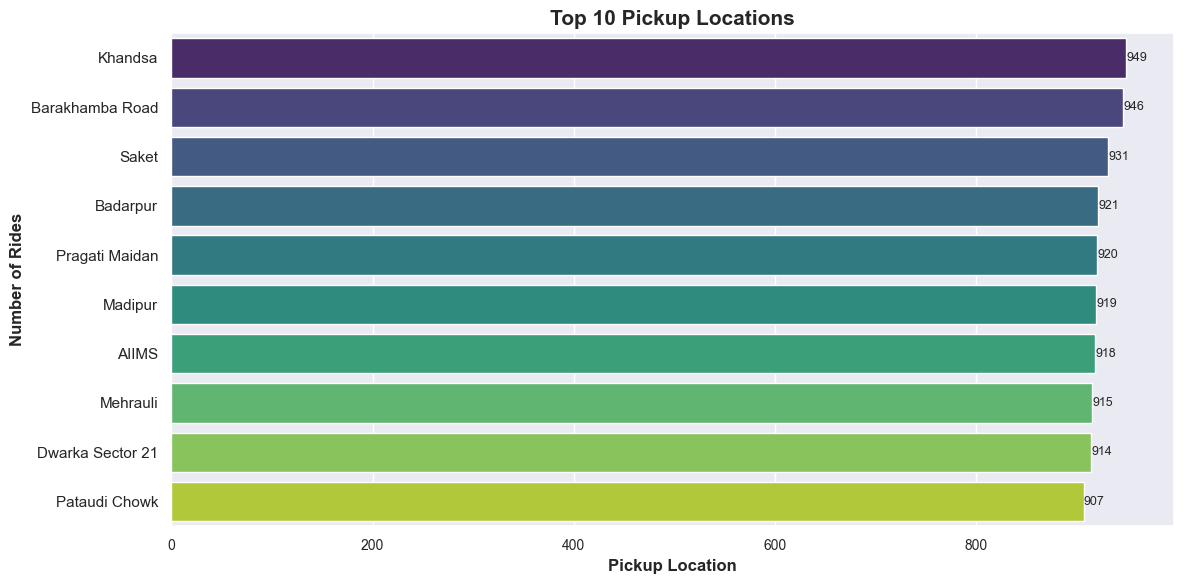

In [14]:
top_10_pickup_locations = df['Pickup Location'].value_counts().head(10)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x = top_10_pickup_locations.values, y = top_10_pickup_locations.index, palette='viridis')

for container in ax.containers:
    ax.bar_label(container, fontsize=9)

plt.title('Top 10 Pickup Locations', fontsize=15, fontweight='bold')
plt.xticks(fontsize=10)
plt.xlabel('Pickup Location', fontsize=12, fontweight='bold')
plt.ylabel('Number of Rides', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Insights

- **Khandsa** recorded the highest number of bookings with **949 rides**, followed by **Barakhamba Road (946)** and **Saket (931)**.

- The top 10 pickup locations have relatively similar booking volumes, ranging from **907 to 949 bookings**, indicating that there is no single pickup location that dominates the overall booking volume among these locations.

- **Khandsa has only 42 more bookings than Pataudi Chowk**, suggesting that booking activity is fairly evenly distributed across the top pickup locations.

## 4- Which drop locations are most popular?

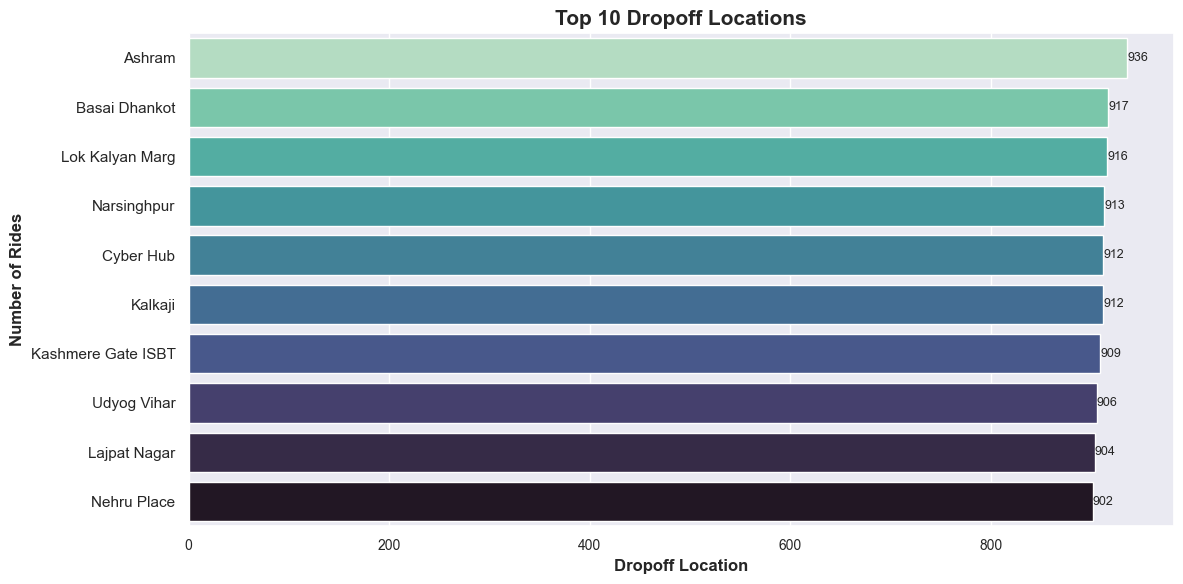

In [15]:
top_10_dropoff_locations = df['Drop Location'].value_counts().head(10)

plt.figure(figsize=(12, 6))
palette = sns.color_palette('mako', n_colors=len(top_10_dropoff_locations))
palette.reverse()
ax = sns.barplot(x = top_10_dropoff_locations.values, y = top_10_dropoff_locations.index, palette=palette)

for container in ax.containers:
    ax.bar_label(container, fontsize=9)

plt.title('Top 10 Dropoff Locations', fontsize=15, fontweight='bold')
plt.xticks(fontsize=10)
plt.xlabel('Dropoff Location', fontsize=12, fontweight='bold')
plt.ylabel('Number of Rides', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Insights

- **Ashram** is the most frequently used drop-off location with **936 bookings**, followed by **Basai Dhankot (917)** and **Lok Kalyan Marg (916)**.

- The top 10 drop-off locations have relatively similar booking volumes, ranging from **902 to 936 bookings**, indicating that there is no single drop-off location that dominates the top locations.

- The difference between the most and least frequent locations in the top 10 is only **34 bookings**, suggesting that drop-off activity is fairly evenly distributed among these locations.

## 5- Which pickup-to-drop-off routes are the most frequently used?

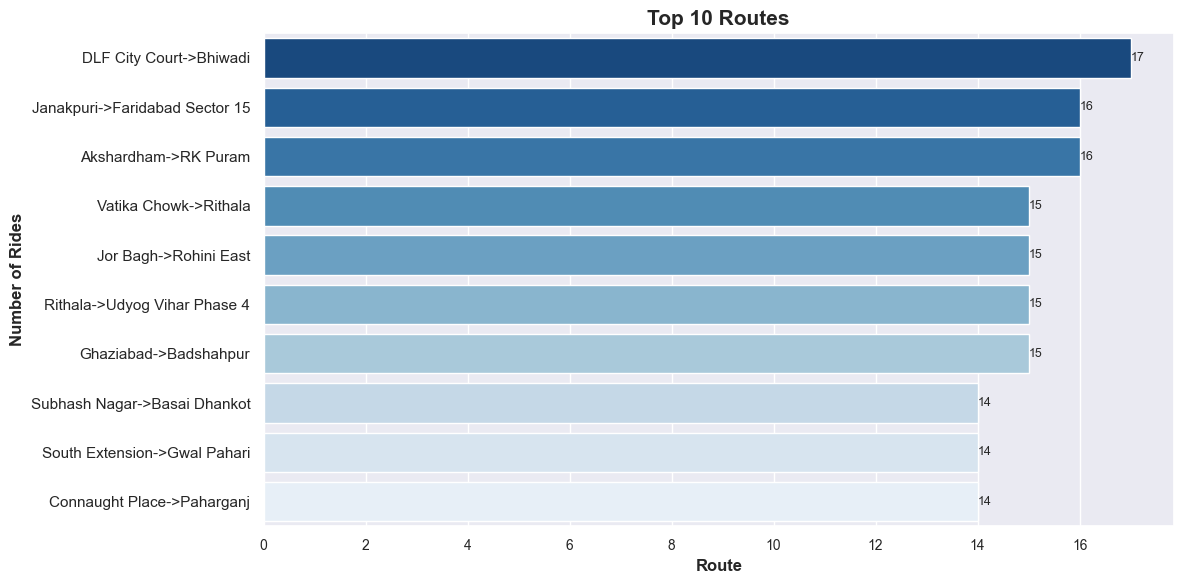

In [16]:
df['route'] = df['Pickup Location'] + '->' + df['Drop Location']
top_10_routes = df['route'].value_counts().head(10)

plt.figure(figsize=(12, 6))
palette = sns.color_palette('Blues', n_colors=len(top_10_routes))
palette.reverse()

ax = sns.barplot(x = top_10_routes.values, y = top_10_routes.index, palette=palette)

for container in ax.containers:
    ax.bar_label(container, fontsize=9)

plt.title('Top 10 Routes', fontsize=15, fontweight='bold')
plt.xticks(fontsize=10)
plt.xlabel('Route', fontsize=12, fontweight='bold')
plt.ylabel('Number of Rides', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Insights

- **DLF City Court → Bhiwadi** is the most frequently used route, with **17 rides**, followed by **Janakpuri → Faridabad Sector 15** and **Akshardham → RK Puram**, with **16 rides each**.

- The top 10 routes have relatively similar frequencies, ranging from **14 to 17 rides**, suggesting that there is **no single route that dominates the overall ride volume**.

- The relatively low number of rides per route also suggests that bookings are distributed across a large number of different pickup-to-drop-off combinations rather than being concentrated on a few major routes.

# 2- Cancellation Analysis

## 1- Does cancellation rate vary by vehicle type?

In [17]:
df['cancelled ride'] = (df['Booking Status'] == 'Cancelled by Driver') | (df['Booking Status'] == 'Cancelled by Customer')

In [18]:
df_canceled_rides = df[(df['Booking Status'] == 'Cancelled by Driver') | (df['Booking Status'] == 'Cancelled by Customer')]

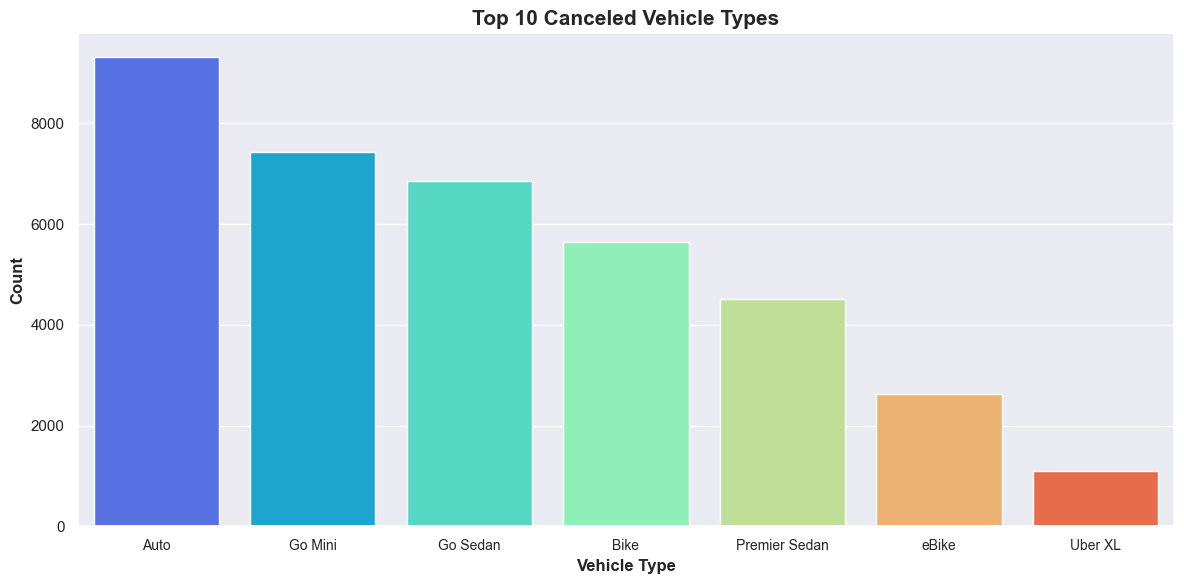

In [19]:
order = df_canceled_rides['Vehicle Type'].value_counts().index

plt.figure(figsize=(12, 6))
sns.countplot(x='Vehicle Type', data=df_canceled_rides, palette='rainbow', order=order)
plt.title('Top 10 Canceled Vehicle Types', fontsize=15, fontweight='bold')
plt.xticks(fontsize=10)
plt.xlabel('Vehicle Type', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

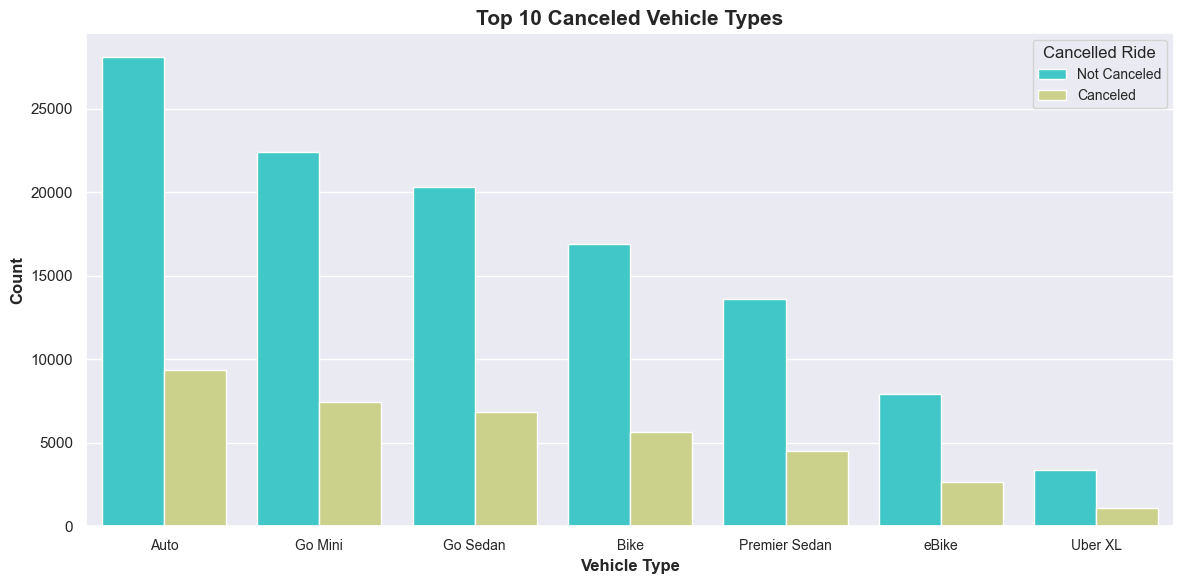

In [20]:
order = df['Vehicle Type'].value_counts().index

plt.figure(figsize=(12, 6))
sns.countplot(x='Vehicle Type', data=df, palette='rainbow', order=order, hue='cancelled ride')
plt.title('Top 10 Canceled Vehicle Types', fontsize=15, fontweight='bold')
plt.xticks(fontsize=10)
plt.xlabel('Vehicle Type', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.legend(title='Cancelled Ride', labels=['Not Canceled', 'Canceled'], fontsize=10, title_fontsize=12)
plt.tight_layout()
plt.show()

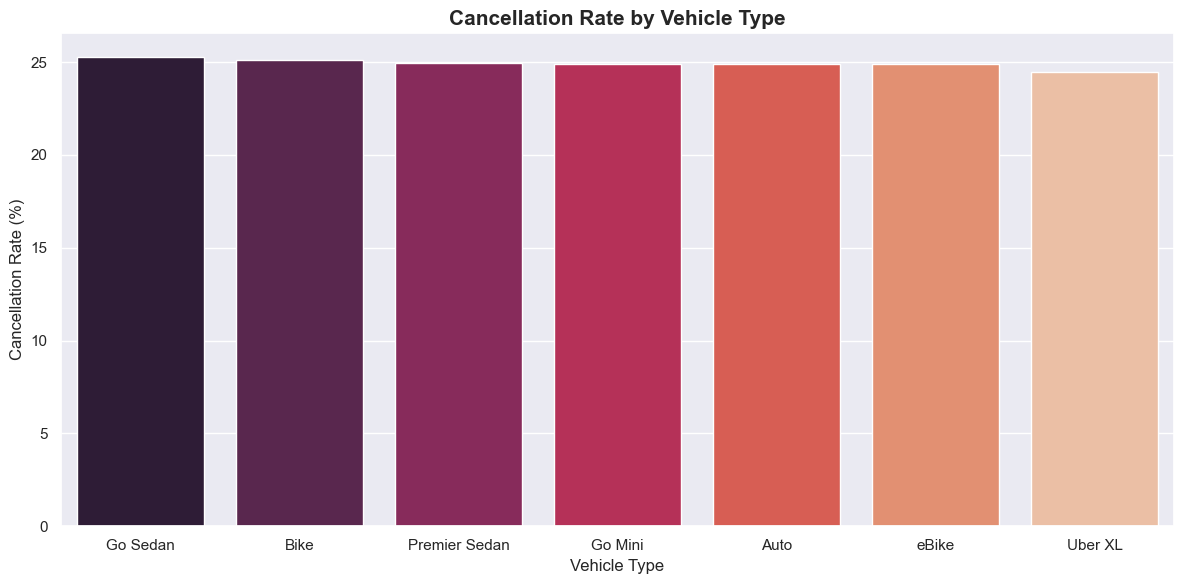

In [21]:
cancellation_by_vehicle = (
    df.groupby('Vehicle Type')
      .agg(
          total_bookings=('Booking ID', 'count'),
          cancelled_bookings=('Booking Status', lambda x: x.str.contains('Cancelled').sum())
      )
)

cancellation_by_vehicle['cancellation_rate'] = (
    cancellation_by_vehicle['cancelled_bookings']
    / cancellation_by_vehicle['total_bookings']
    * 100
)

sorted_cancellation_by_vehicle = cancellation_by_vehicle.sort_values(
    'cancellation_rate',
    ascending=False
)

plt.figure(figsize=(12, 6))
sns.barplot(data=sorted_cancellation_by_vehicle.reset_index(), 
            x='Vehicle Type', y='cancellation_rate', palette='rocket')
plt.title('Cancellation Rate by Vehicle Type', fontsize=15, fontweight='bold')
plt.xlabel('Vehicle Type', fontsize=12)
plt.ylabel('Cancellation Rate (%)', fontsize=12)
plt.tight_layout()
plt.show()


### Key Insights

- **Go Sedan** has the highest cancellation rate at **25.29%**, while **Uber XL** has the lowest at **24.48%**.

- Cancellation rates are remarkably consistent across all vehicle types, ranging from **24.48% to 25.29%**.

- The difference between the highest and lowest cancellation rates is only **0.81 percentage points**, suggesting that **vehicle type is not a major differentiating factor in cancellation behavior** within this dataset.

## 2- Does cancellation vary by time?

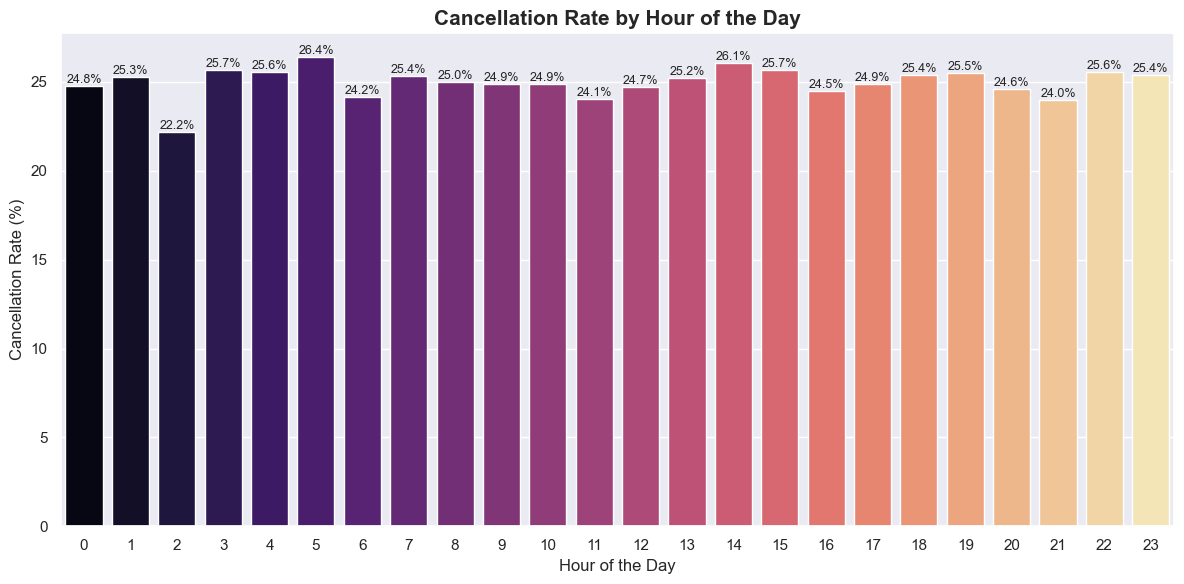

In [22]:
hourly_cancellations = df.groupby('hour').agg(
    total_bookings=('Booking ID', 'count'),
    cancelled_bookings=('Booking Status', lambda x: x.str.contains('Cancelled').sum())
)

hourly_cancellations['cancellation_rate'] = (
    hourly_cancellations['cancelled_bookings']
    / hourly_cancellations['total_bookings']
    * 100
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(data=hourly_cancellations.reset_index(),
            x='hour', y='cancellation_rate', palette='magma')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9)

plt.title('Cancellation Rate by Hour of the Day', fontsize=15, fontweight='bold')
plt.xlabel('Hour of the Day', fontsize=12)
plt.ylabel('Cancellation Rate (%)', fontsize=12)
plt.tight_layout()
plt.show()

### Key Insights

- **5 AM** has the highest cancellation rate at **26.42%**, while **2 AM** has the lowest at **22.18%**.

- Despite the differences between individual hours, cancellation rates remain relatively consistent, with most hours falling between **24% and 26%**.

- The evening has the highest **number of cancelled rides**, particularly around **6–8 PM**, but this is largely associated with the higher booking volume during these hours.

- Overall, **hour of the day does not appear to have a strong effect on cancellation rate**, as the cancellation rate remains relatively stable across most hours.

## 3- What is the most common cancellation reason?

In [23]:
# Using Plotly
customer_cancel_reasons = (
    df_canceled_rides['Reason for cancelling by Customer']
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

customer_cancel_reasons.columns = ['Cancellation Reason', 'Percentage']

fig = px.bar(customer_cancel_reasons,
            y='Cancellation Reason',
            x='Percentage',
            color='Cancellation Reason',
            title='Most Common Cancellation Reasons by Customers',
            labels={
                'Percentage': 'Percentage of Cancellations (%)',
                'Cancellation Reason': 'Cancellation Reason'
            }
)
fig.show()

### Key Insights

- **Wrong Address** is the most common customer cancellation reason, accounting for **22.4%**, followed closely by **Change of Plans (22.4%)** and **Driver is not moving towards pickup location (22.2%)**.

- **Driver asked to cancel** is also a major contributor, with **21.8%**.

- **AC is not working** is considerably less common, with **11%**, representing roughly half the cancellations of the leading reasons.

- Overall, the results suggest that **most customer cancellations are related to trip logistics and driver-related issues**, rather than vehicle-specific problems such as AC failure.

# 3- Revenue Analysis

## 1- what was the revenue distribution through out the whole year?

In [24]:
months_revenue = df.groupby('month_name', as_index=False)[['Booking Value']].sum()

months_revenue['month_name'] = pd.Categorical(
    months_revenue['month_name'],
    categories= month_order,
    ordered=True
)

months_revenue = months_revenue.sort_values('month_name')

fig = px.bar(
    months_revenue,
    x='month_name',
    y='Booking Value',
    title='Total Booking Value by Month',
    labels={
        'month_name': 'Month',
        'Booking Value': 'Total Booking Value'
    },
    text_auto='.2s',
    color='month_name',
)

fig.update_layout(
    xaxis_title=None,
    yaxis_title='Total Booking Value',
    template='plotly_dark'
)

fig.show()

### Key Insights

### Key Insight

- **March** generated the highest revenue of approximately **4.6M**, while **February** recorded the lowest at approximately **4.1M**. This represents a relatively small difference of around **0.5M**, suggesting that monthly revenue remained fairly stable throughout the year.

## 2- Which vehicle type generates the most revenue?

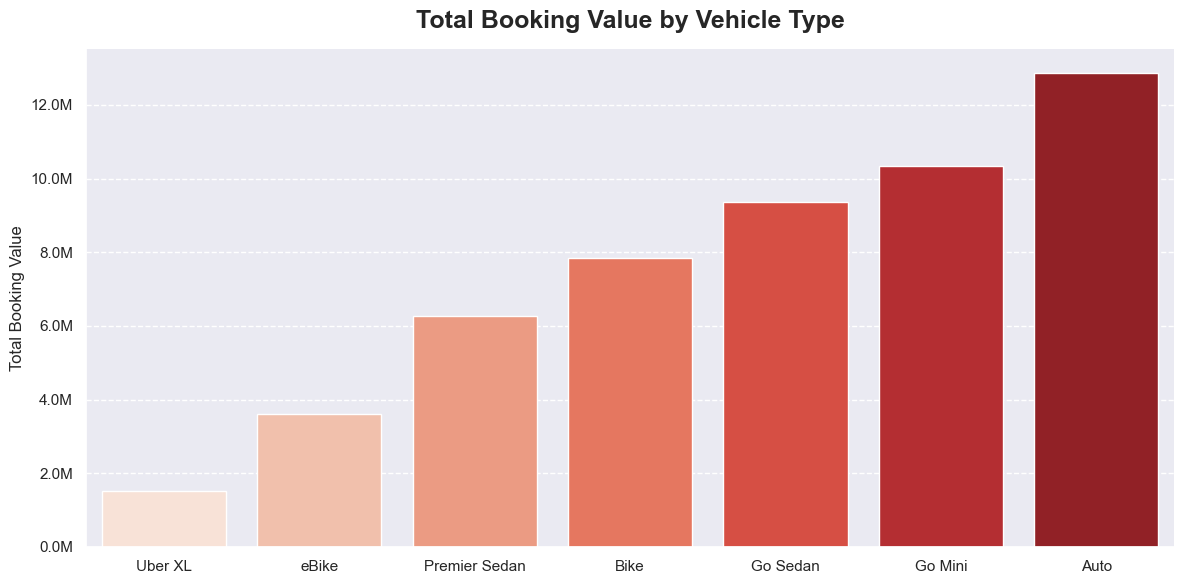

In [25]:
from matplotlib.ticker import FuncFormatter

vehicle_revenue = (
    df.groupby('Vehicle Type', as_index=False)['Booking Value']
      .sum()
      .sort_values('Booking Value', ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=vehicle_revenue,
    x='Vehicle Type',
    y='Booking Value',
    palette='Reds',
    ax=ax
)

ax.set_title(
    'Total Booking Value by Vehicle Type',
    fontsize=18,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('')
ax.set_ylabel('Total Booking Value', fontsize=12)

# Format y-axis as millions
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x / 1_000_000:.1f}M')
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(
    axis='y',
    linestyle='--',
)

plt.tight_layout()
plt.show()

### Key Insights

- **Auto** generates the highest total revenue at approximately **12.88M**, followed by **Go Mini (10.34M)** and **Go Sedan (9.37M)**.

- **Uber XL** generates the lowest total revenue at approximately **1.53M**.

- The higher revenue generated by Auto is likely influenced by its larger booking volume. Therefore, total revenue alone does not indicate which vehicle type generates the most revenue **per ride**.

## 3- What is the Average Revenue per Ride by Vehicle?

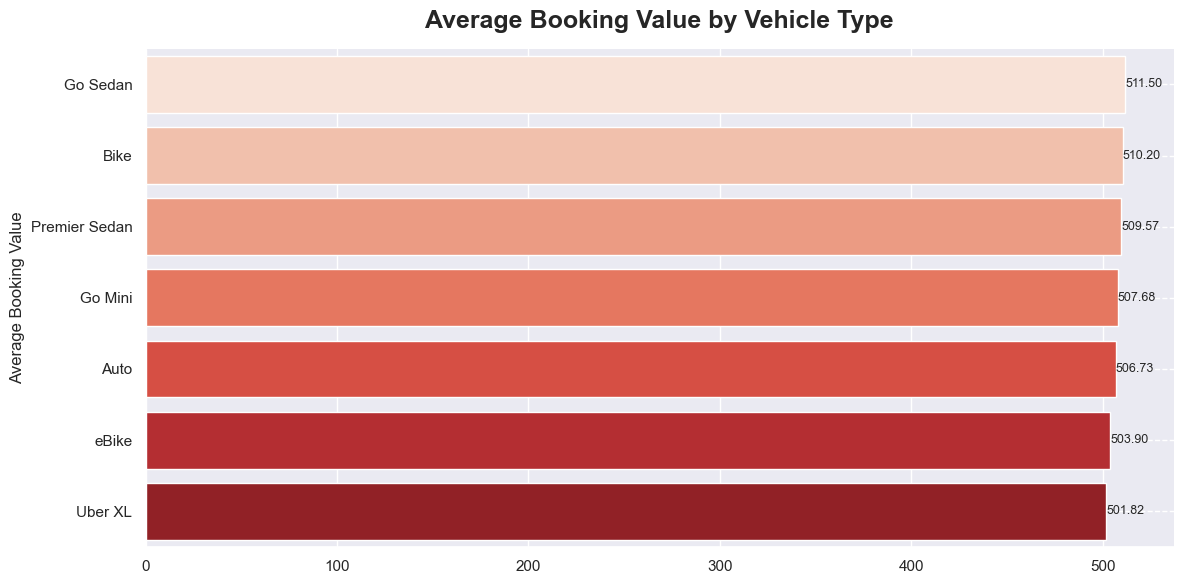

In [26]:
revenue_per_ride = (
    df.groupby('Vehicle Type', as_index=False)['Booking Value']
    .agg(['sum', 'count'])
)

revenue_per_ride['avg_revenue_per_ride'] = revenue_per_ride['sum'] / revenue_per_ride['count']

revenue_per_ride.sort_values('avg_revenue_per_ride', ascending=False, inplace=True)


fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=revenue_per_ride,
    x='avg_revenue_per_ride',
    y='Vehicle Type',
    palette='Reds',
    ax=ax
)

ax.set_title(
    'Average Booking Value by Vehicle Type',
    fontsize=18,
    fontweight='bold',
    pad=15
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9)

ax.set_xlabel('')
ax.set_ylabel('Average Booking Value', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(
    axis='y',
    linestyle='--',
)

plt.tight_layout()
plt.show()

### Key Insights

- **Go Sedan** generates the highest average revenue per ride at approximately **511.50**, while **Uber XL** has the lowest at approximately **501.82**.

- Although **Auto** generates the highest total revenue, its average revenue per ride is lower than Go Sedan. This indicates that Auto's high total revenue is primarily driven by its **larger booking volume**.

- The average revenue per ride is relatively consistent across vehicle types, with only about **9.69** separating the highest and lowest averages.

## 4- Which payment method generates the most revenue?

In [27]:
payment_revenue = (
    df.groupby('Payment Method', as_index=False)['Booking Value']
      .sum()
      .sort_values('Booking Value', ascending=True)
      .rename(columns={'Booking Value': 'Revenue'})
)

fig = px.pie(
    payment_revenue,
    names='Payment Method',
    values='Revenue',
    title='Revenue Distribution by Payment Method',
    hole=0.4
)

fig.update_traces(
    textposition='inside',
    textinfo='percent+label'
)

fig.show()

### Key Insights

- **UPI** is the largest contributor to total revenue, generating approximately **23.35M**, which represents about **44.5%** of total revenue.

- **Cash** is the second-largest contributor, generating approximately **12.90M**.

- **Debit Card** contributes the least revenue at approximately **4.18M**.

- UPI generates nearly **twice the revenue of Cash**, making it the dominant payment method in terms of revenue contribution.

## 5- Does distance explain booking value?

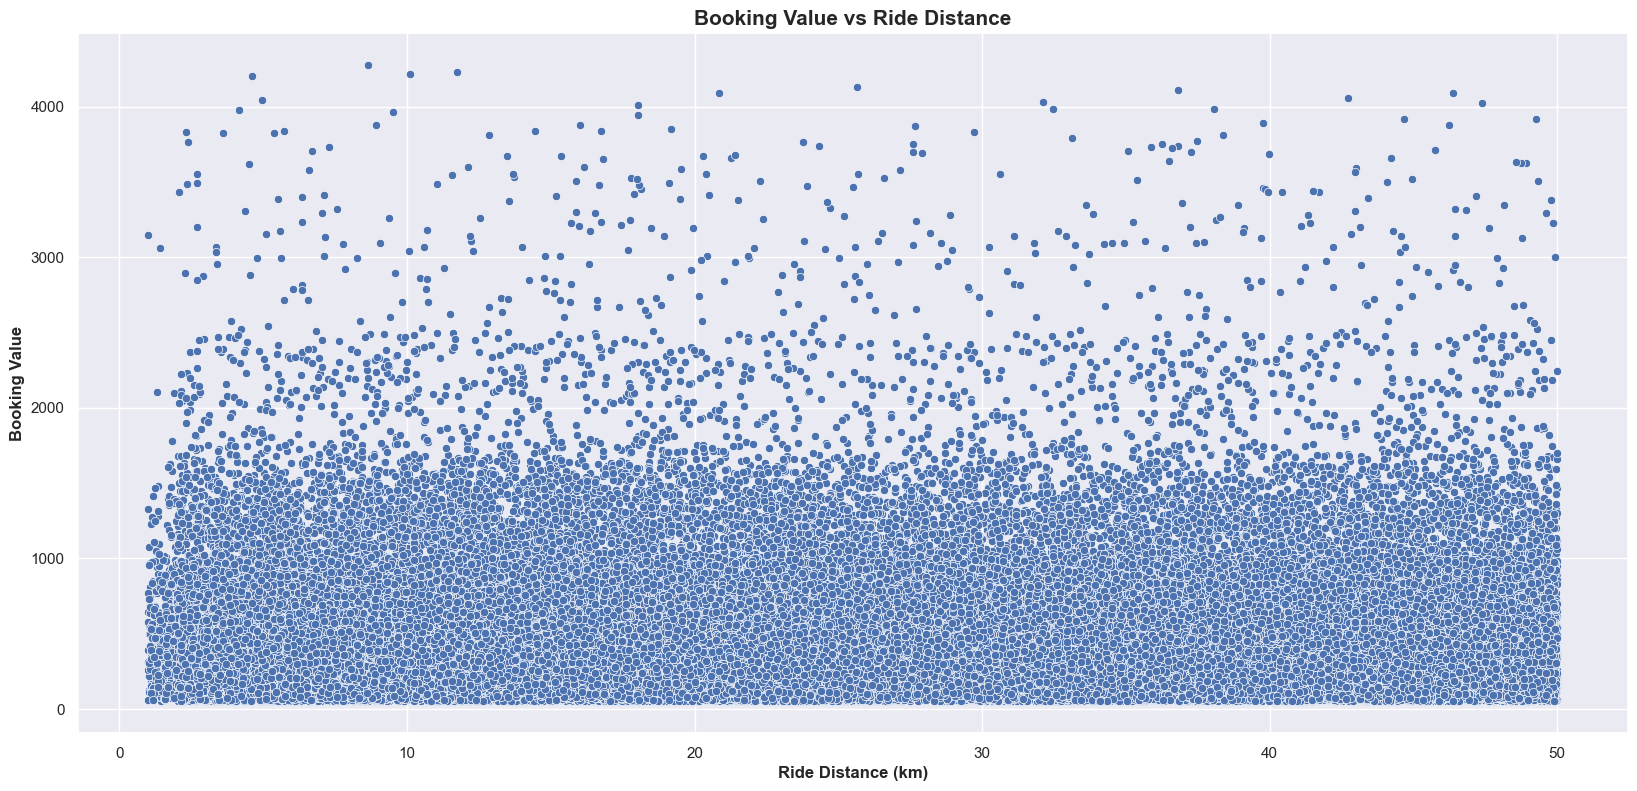

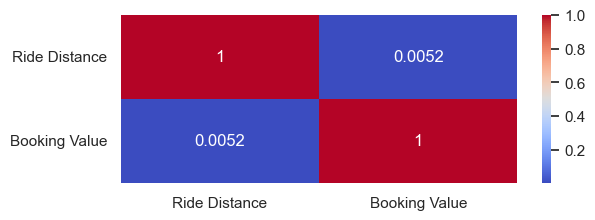

In [28]:
plt.figure(figsize=(20, 20))

plt.subplot(2, 1, 1)
sns.scatterplot(
    data=df,
    x='Ride Distance',
    y='Booking Value',
)

plt.title('Booking Value vs Ride Distance', fontsize=15, fontweight='bold')
plt.xlabel('Ride Distance (km)', fontsize=12, fontweight='bold')
plt.ylabel('Booking Value', fontsize=12, fontweight='bold')
plt.show()

plt.subplot(2, 1, 2)
corr = df[["Ride Distance", "Booking Value"]].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

### Key Insight

- The correlation between **Ride Distance** and **Booking Value** is approximately **0.005**, indicating an almost nonexistent linear relationship between trip distance and booking value in this dataset.

- This suggests that **longer rides do not necessarily result in higher booking values**, indicating that other factors may have a stronger influence on the fare.